---
Author: The Tuan Trinh \
Date: 01/06/2026
---

In [1]:
import os
import platform
print("=" * 100)
print("OS Name:", os.name)
print("System:", platform.system())
print("Release:", platform.release())
print("Machine:", platform.machine())
print("Processor:", platform.processor())
print("Platform:", platform.platform())

print("\nEnvironment Variables (sample):")
for key, value in list(os.environ.items())[:15]:
    print(f"{key} = {value}")

OS Name: nt
System: Windows
Release: 10
Machine: AMD64
Processor: Intel64 Family 6 Model 142 Stepping 12, GenuineIntel
Platform: Windows-10-10.0.26200-SP0

Environment Variables (sample):
ALLUSERSPROFILE = C:\ProgramData
APPDATA = C:\Users\Admin\AppData\Roaming
APPLICATION_INSIGHTS_NO_STATSBEAT = true
CHROME_CRASHPAD_PIPE_NAME = \\.\pipe\crashpad_1956_PNLGHBSPHHYQZDLU
COMMONPROGRAMFILES = C:\Program Files\Common Files
COMMONPROGRAMFILES(X86) = C:\Program Files (x86)\Common Files
COMMONPROGRAMW6432 = C:\Program Files\Common Files
COMPUTERNAME = PMH
COMSPEC = C:\Windows\system32\cmd.exe
CONDA_DEFAULT_ENV = PMH
CONDA_EXE = C:\Users\Admin\miniconda3\Scripts\conda.exe
CONDA_PREFIX = C:\Users\Admin\miniconda3\envs\PMH
CONDA_PROMPT_MODIFIER = (PMH) 
CONDA_PYTHON_EXE = C:\Users\Admin\miniconda3\python.exe
CONDA_ROOT = C:\Users\Admin\miniconda3


In [2]:
platform.python_version()

'3.10.20'

# Lab 12 - Nhận dạng 3 vật thể

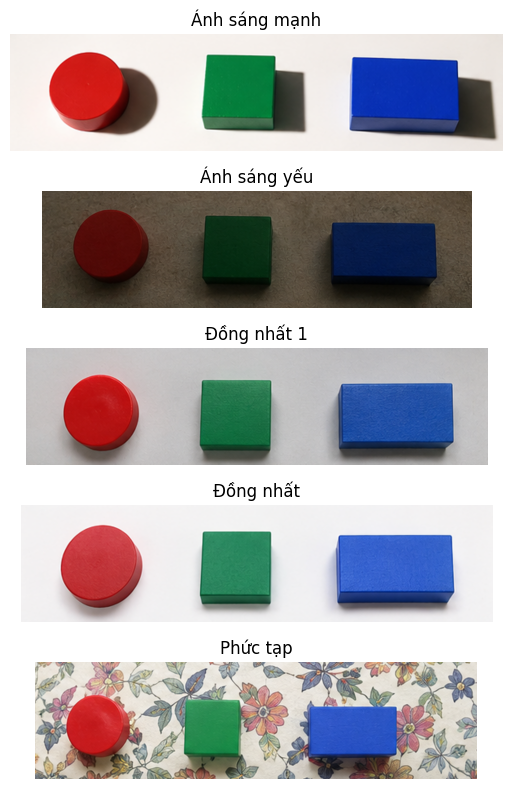

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

anh_sang_manh = cv2.imread("anh sang manh.png")
anh_sang_yeu  = cv2.imread("anh sang yeu.png")
dong_nhat_1   = cv2.imread("dong nhat 1.png")
dong_nhat     = cv2.imread("dong nhat.png")
phuc_tap      = cv2.imread("phuc tap.png")
images = [
    ("Ánh sáng mạnh", anh_sang_manh),
    ("Ánh sáng yếu", anh_sang_yeu),
    ("Đồng nhất 1", dong_nhat_1),
    ("Đồng nhất", dong_nhat),
    ("Phức tạp", phuc_tap)
]
plt.figure(figsize=(15, 8))
for i, (title, img) in enumerate(images, start=1):
    plt.subplot(5, 1, i)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.imshow(img_rgb)
    plt.title(title)
    plt.axis("off")
plt.tight_layout()
plt.show()

In [4]:
def detect_shape(image):
    output = image.copy()
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    lower_red1 = np.array([0, 50, 50])
    upper_red1 = np.array([10, 255, 255])
    lower_red2 = np.array([170, 50, 50])
    upper_red2 = np.array([180, 255, 255])
    lower_green = np.array([35, 40, 40])
    upper_green = np.array([85, 255, 255])
    lower_blue = np.array([90, 40, 40])
    upper_blue = np.array([140, 255, 255])
    mask_red = cv2.inRange(hsv, lower_red1, upper_red1) + \
               cv2.inRange(hsv, lower_red2, upper_red2)
    mask_green = cv2.inRange(hsv, lower_green, upper_green)
    mask_blue = cv2.inRange(hsv, lower_blue, upper_blue)
    masks = [
        ("Circle", mask_red),
        ("Square", mask_green),
        ("Rectangle", mask_blue)
    ]
    for name, mask in masks:
        kernel = np.ones((5,5), np.uint8)
        mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
        contours, _ = cv2.findContours(
            mask,
            cv2.RETR_EXTERNAL,
            cv2.CHAIN_APPROX_SIMPLE
        )
        for cnt in contours:
            area = cv2.contourArea(cnt)
            if area < 500:
                continue
            x, y, w, h = cv2.boundingRect(cnt)
            cv2.drawContours(
                output,
                [cnt],
                -1,
                (0,255,0),
                2
            )
            cv2.putText(
                output,
                name,
                (x, y-10),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.7,
                (255,0,0),
                2
            )

    return output

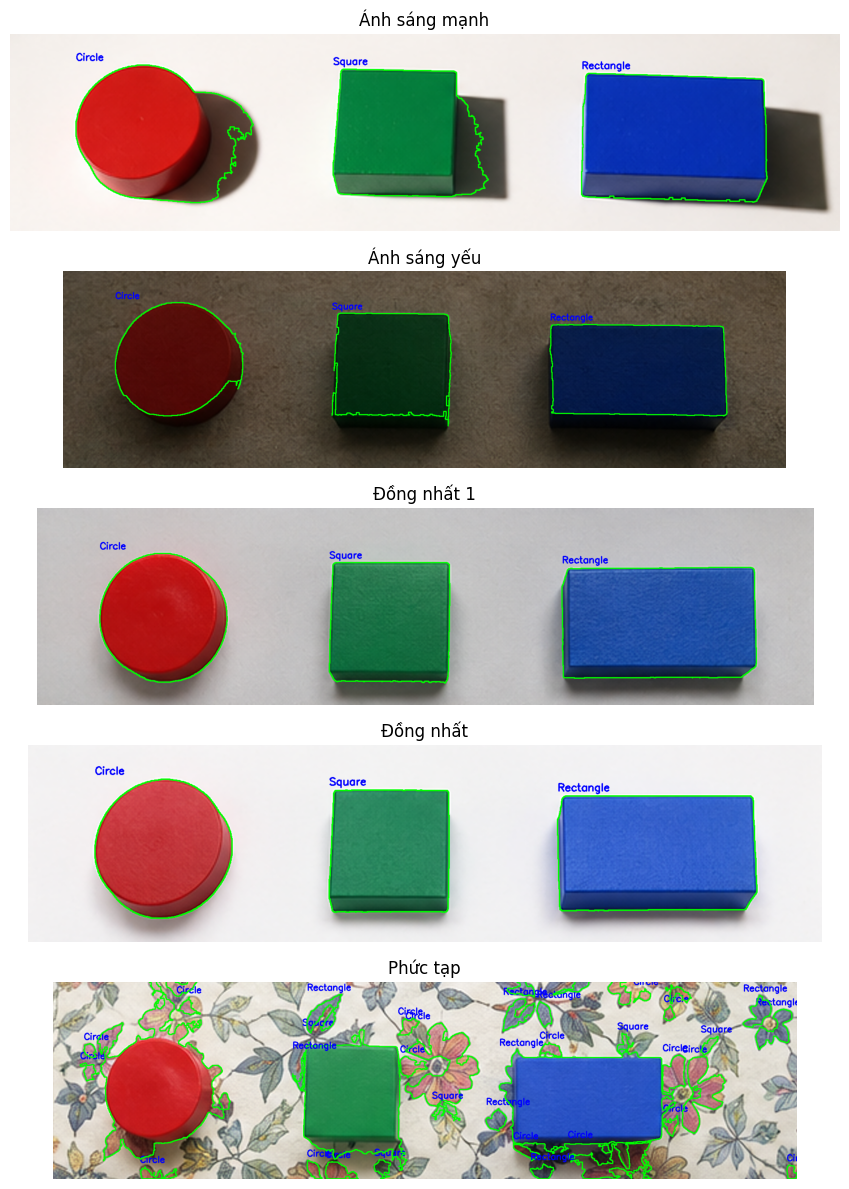

In [5]:
plt.figure(figsize=(15, 12))
for i, (title, img) in enumerate(images, start=1):
    result = detect_shape(img)
    plt.subplot(5, 1, i)
    plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis("off")
plt.tight_layout()
plt.show()